In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

path = r"C:\Users\Arifi\Desktop\FORECASTING OBAT\data\processed\Concat.csv"
label = r"C:\Users\Arifi\Desktop\FORECASTING OBAT\data\final\label.xlsx"

df = pd.read_csv(path, low_memory=False)
label = pd.read_excel(label)

df['Tanggal Transaksi'] = pd.to_datetime(df['Tanggal Transaksi'])
print(df.shape)
print(df.dtypes)

(27346, 14)
No                            int64
Tanggal Transaksi    datetime64[us]
Kode Struk                      str
Kode Produk                     str
Nama Produk                     str
Barcode                     float64
Kategori 1                      str
Jumlah                        int64
Satuan                          str
ED                              str
Kode Batch                      str
Harga Jual                    int64
Pelanggan                   float64
Kanal Penjualan             float64
dtype: object


In [2]:
print("Rentang tanggal:", df['Tanggal Transaksi'].min(), "→", df['Tanggal Transaksi'].max())
print("Total SKU unik:", df['Kode Produk'].nunique())
print("Total baris:", len(df))
print("\nKategori 1 (dari sistem kasir):")
print(df['Kategori 1'].value_counts(dropna=False))

Rentang tanggal: 2025-04-04 00:00:00 → 2026-04-30 00:00:00
Total SKU unik: 1470
Total baris: 27346

Kategori 1 (dari sistem kasir):
Kategori 1
NaN        27035
TABLET       218
BUNGKUS       93
Name: count, dtype: int64


In [3]:
label['cat_norm'] = label['Draf_Kategori'].str.strip().str.lower()
print("Distribusi kategori di label:")
print(label['cat_norm'].value_counts())

obat_skus = set(label[label['cat_norm'] == 'obat']['SKU'].dropna().unique())
print(f"\nTotal SKU obat di master data: {len(obat_skus)}")

Distribusi kategori di label:
cat_norm
obat          937
fmcg          436
kosmetik      102
alkes_bmhp     65
alkes          30
Name: count, dtype: int64

Total SKU obat di master data: 937


In [4]:
df_obat = df[df['Kode Produk'].isin(obat_skus)].copy()

print(f"Baris transaksi obat: {len(df_obat)}")
print(f"SKU obat yang pernah bertransaksi: {df_obat['Kode Produk'].nunique()}")
print(f"SKU obat dengan NOL transaksi: {len(obat_skus) - df_obat['Kode Produk'].nunique()}")

Baris transaksi obat: 18404
SKU obat yang pernah bertransaksi: 847
SKU obat dengan NOL transaksi: 90


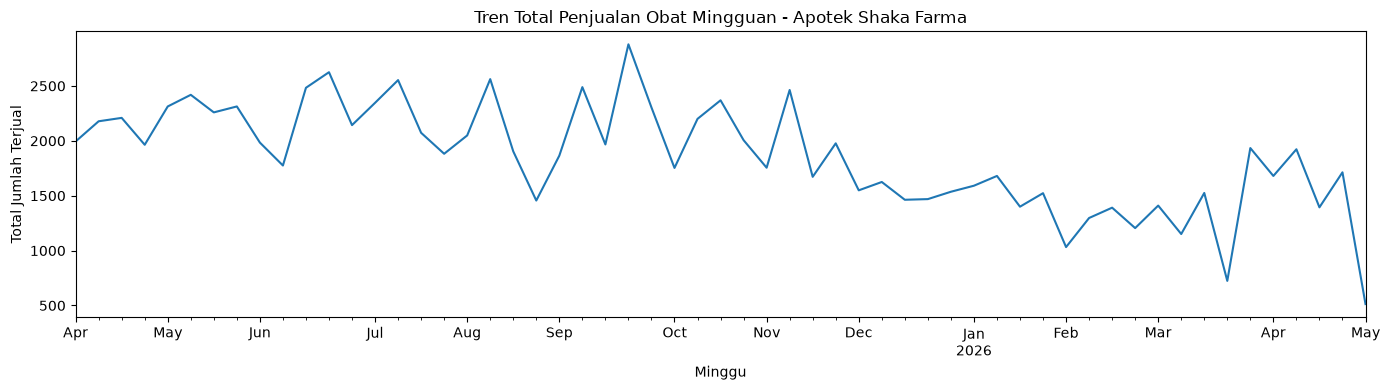

In [5]:
df_obat['week'] = df_obat['Tanggal Transaksi'].dt.to_period('W-MON')
weekly_total = df_obat.groupby('week')['Jumlah'].sum()

plt.figure(figsize=(14, 4))
weekly_total.plot()
plt.title('Tren Total Penjualan Obat Mingguan - Apotek Shaka Farma')
plt.xlabel('Minggu')
plt.ylabel('Total Jumlah Terjual')
plt.tight_layout()
plt.show()

Total minggu observasi: 57
Fast-moving (≥17 minggu aktif): 195
Slow-moving (<17 minggu aktif): 742


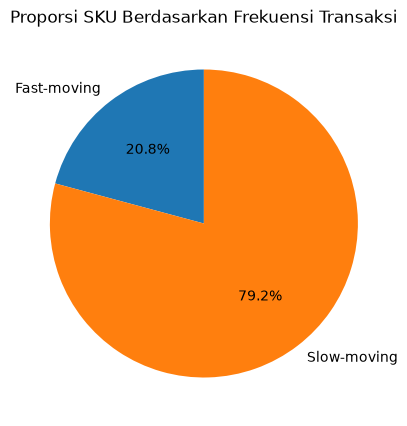

In [6]:
all_weeks = pd.period_range(df_obat['Tanggal Transaksi'].min(),
                             df_obat['Tanggal Transaksi'].max(), freq='W-MON')
total_weeks = len(all_weeks)
print(f"Total minggu observasi: {total_weeks}")

weeks_active = df_obat[df_obat['Jumlah'] > 0].groupby('Kode Produk')['week'].nunique()
fast = (weeks_active >= 17).sum()
slow = (weeks_active < 17).sum()
zero = len(obat_skus) - len(weeks_active)

print(f"Fast-moving (≥17 minggu aktif): {fast}")
print(f"Slow-moving (<17 minggu aktif): {slow + zero}")

labels = ['Fast-moving', 'Slow-moving']
sizes = [fast, slow + zero]
plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Proporsi SKU Berdasarkan Frekuensi Transaksi')
plt.show()

In [7]:
weekly_per_sku = df_obat.groupby('Kode Produk')['week'].nunique()
zero_weeks = total_weeks - weekly_per_sku

print("Statistik minggu tanpa transaksi per SKU:")
print(zero_weeks.describe())
print(f"\nSKU dengan >50% minggu kosong: {(zero_weeks > total_weeks*0.5).sum()}")

Statistik minggu tanpa transaksi per SKU:
count    847.000000
mean      45.709563
std       11.976758
min        2.000000
25%       41.000000
50%       50.000000
75%       55.000000
max       56.000000
Name: week, dtype: float64

SKU dengan >50% minggu kosong: 754


Statistik kuantitas penjualan (Jumlah):
count    18404.000000
mean         5.754782
std          7.789640
min          1.000000
25%          1.000000
50%          1.000000
75%         10.000000
max        160.000000
Name: Jumlah, dtype: float64


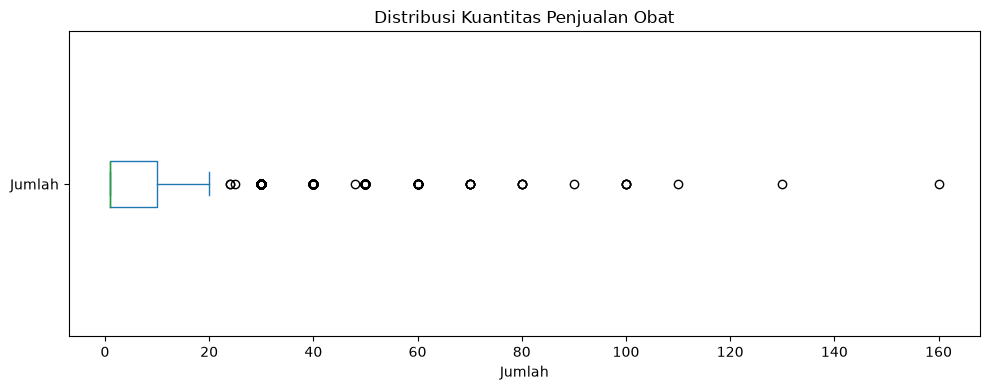


Top 10 transaksi volume tertinggi:
      Tanggal Transaksi Kode Produk           Nama Produk  Jumlah Satuan
119          2025-04-05   OB-CAR075          CARBIDU 0,75     160  Butir
110          2025-04-05    OB-WIR20              WIROS 20     130  Butir
129          2025-04-05      OB-TEO               TEOSAL      110  Strip
215          2025-04-07      OB-TEO               TEOSAL      100  Strip
13795        2025-10-15   OB-DEXPLU         DEXTEEM PLUS      100  Butir
22230        2026-02-15      OB-HUF            HUFRALGIN      100  Butir
25061        2026-03-31      OB-VOL              VOLTADEX     100  Butir
22228        2026-02-15      OB-VOL              VOLTADEX      90  Butir
7478         2025-07-08   OB-SIM10M  SIMVASTATIN 10MG TAB      80  Strip
16498        2025-11-23   OB-SIM10M  SIMVASTATIN 10MG TAB      80  Strip


In [8]:
print("Statistik kuantitas penjualan (Jumlah):")
print(df_obat['Jumlah'].describe())

plt.figure(figsize=(10, 4))
df_obat['Jumlah'].plot(kind='box', vert=False)
plt.title('Distribusi Kuantitas Penjualan Obat')
plt.xlabel('Jumlah')
plt.tight_layout()
plt.show()

# Top 10 transaksi terbesar
print("\nTop 10 transaksi volume tertinggi:")
print(df_obat.nlargest(10, 'Jumlah')[['Tanggal Transaksi','Kode Produk','Nama Produk','Jumlah','Satuan']])

In [9]:
satuan_per_sku = df_obat.groupby('Kode Produk')['Satuan'].nunique()
inkonsisten = satuan_per_sku[satuan_per_sku > 1]

print(f"SKU dengan satuan konsisten (1 satuan): {(satuan_per_sku == 1).sum()}")
print(f"SKU dengan satuan INKONSISTEN (>1 satuan): {len(inkonsisten)}")

if len(inkonsisten) > 0:
    print("\nDetail SKU inkonsisten:")
    for sku in inkonsisten.index:
        satuans = df_obat[df_obat['Kode Produk'] == sku]['Satuan'].unique()
        nama = df_obat[df_obat['Kode Produk'] == sku]['Nama Produk'].iloc[0]
        print(f"  {sku} | {nama} | {satuans}")

SKU dengan satuan konsisten (1 satuan): 847
SKU dengan satuan INKONSISTEN (>1 satuan): 0
